# Predicting Temperatures in London for years to come

## Exploratory Data Analysis (EDA) and Data Cleaning

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.offline as pyo
import plotly.graph_objs as go
import plotly.express as px
import numpy as np

In [7]:
df = pd.read_csv(r'C:\Users\HP\KaggleDatasets\london_weather.csv')

In [8]:
df.head()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,19790101,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,19790102,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,19790103,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,19790104,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,19790105,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15341 entries, 0 to 15340
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              15341 non-null  int64  
 1   cloud_cover       15322 non-null  float64
 2   sunshine          15341 non-null  float64
 3   global_radiation  15322 non-null  float64
 4   max_temp          15335 non-null  float64
 5   mean_temp         15305 non-null  float64
 6   min_temp          15339 non-null  float64
 7   precipitation     15335 non-null  float64
 8   pressure          15337 non-null  float64
 9   snow_depth        13900 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 1.2 MB


In [10]:
duplicates = df[df.duplicated(subset=['date'], keep = False )]
print(duplicates)

Empty DataFrame
Columns: [date, cloud_cover, sunshine, global_radiation, max_temp, mean_temp, min_temp, precipitation, pressure, snow_depth]
Index: []


In [11]:
missing_columns = df.columns[df.isnull().any()]
print(missing_columns)

Index(['cloud_cover', 'global_radiation', 'max_temp', 'mean_temp', 'min_temp',
       'precipitation', 'pressure', 'snow_depth'],
      dtype='object')


In [12]:
df.fillna(0, inplace=True)

In [13]:
missing_columns = df.columns[df.isnull().any()]
print(missing_columns)

Index([], dtype='object')


In [14]:
df = df.drop('snow_depth', axis=1)

### Detecting Outliers

In [16]:
Q1 = df["max_temp"].quantile(0.25)
Q3 = df["max_temp"].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
df_cleaned = df[(df["max_temp"] >= lower_bound) & (df["max_temp"] <= upper_bound)]

print(df_cleaned)

           date  cloud_cover  sunshine  global_radiation  max_temp  mean_temp  \
0      19790101          2.0       7.0              52.0       2.3       -4.1   
1      19790102          6.0       1.7              27.0       1.6       -2.6   
2      19790103          5.0       0.0              13.0       1.3       -2.8   
3      19790104          8.0       0.0              13.0      -0.3       -2.6   
4      19790105          6.0       2.0              29.0       5.6       -0.8   
...         ...          ...       ...               ...       ...        ...   
15336  20201227          1.0       0.9              32.0       7.5        7.5   
15337  20201228          7.0       3.7              38.0       3.6        1.1   
15338  20201229          7.0       0.0              21.0       4.1        2.6   
15339  20201230          6.0       0.4              22.0       5.6        2.7   
15340  20201231          7.0       1.3              34.0       1.5       -0.8   

       min_temp  precipitat

### Data Visualization

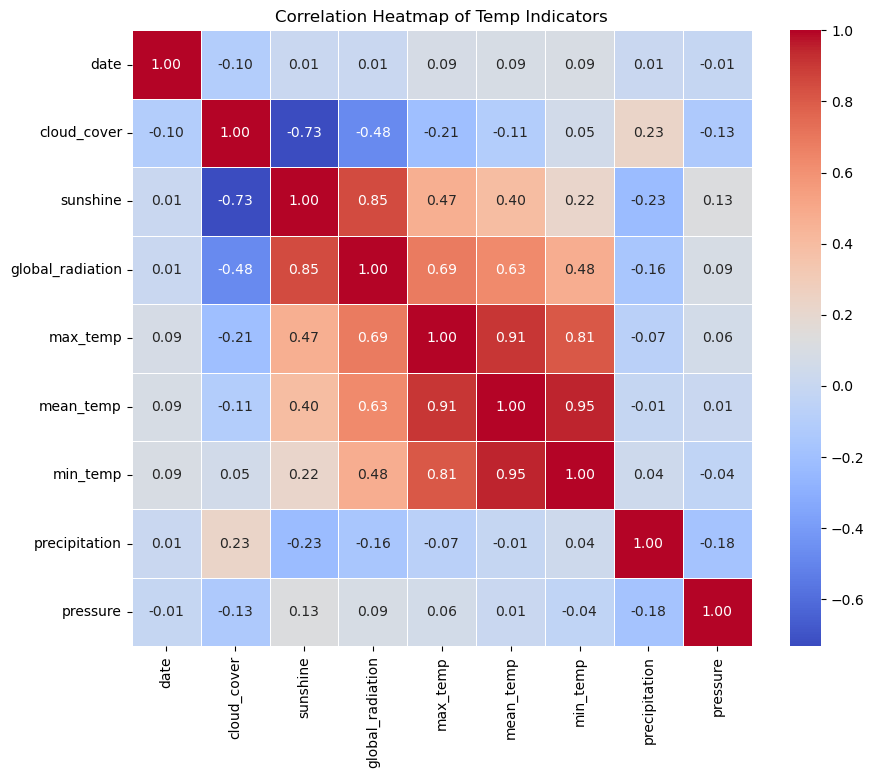

In [18]:
df_numeric = df.select_dtypes(include=['number'])  
corr_matrix = df_numeric.corr()  

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, linewidths=0.5)

# Title and labels
plt.title('Correlation Heatmap of Temp Indicators')
plt.show()

## Pre Processing

In [34]:
from statsmodels.tsa.stattools import adfuller

In [36]:
def adf_test(series):
    result = adfuller(series)
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] < 0.05:
        print("The data is stationary")
    else:
        print("The data is non-stationary")

adf_test(df["max_temp"])

ADF Statistic: -8.706404581757678
p-value: 3.690108978888665e-14
The data is stationary


In [38]:
adf_test(df["mean_temp"])

ADF Statistic: -7.8454502156801835
p-value: 5.785691260065544e-12
The data is stationary


In [40]:
adf_test(df["min_temp"])

ADF Statistic: -8.294553592857035
p-value: 4.173958625584385e-13
The data is stationary


In [42]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

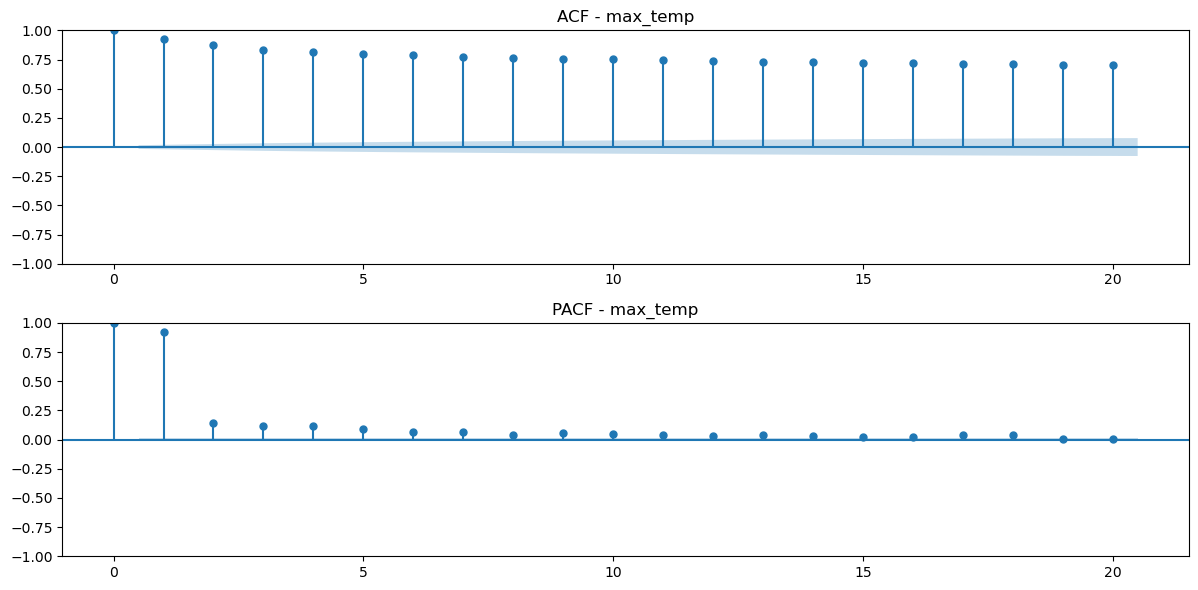

In [44]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plot_acf(df["max_temp"], lags=20, ax=plt.gca())  
plt.title("ACF - max_temp")

plt.subplot(2, 1, 2)
plot_pacf(df["max_temp"], lags=20, ax=plt.gca())  
plt.title("PACF - max_temp")

plt.tight_layout()
plt.show()

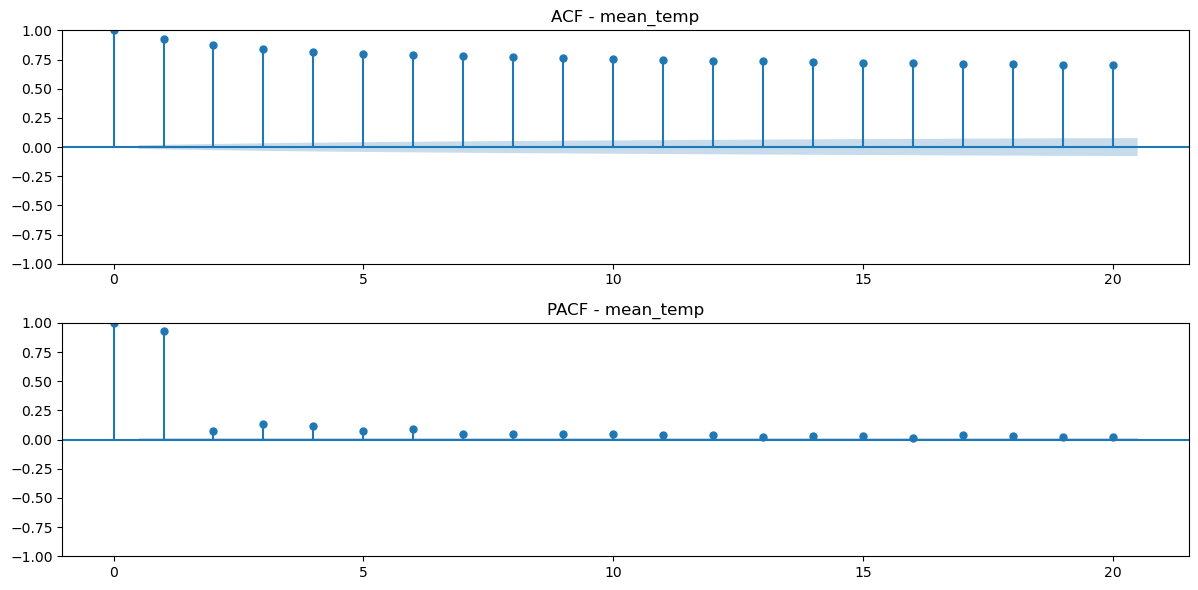

In [46]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plot_acf(df["mean_temp"], lags=20, ax=plt.gca())  
plt.title("ACF - mean_temp")

plt.subplot(2, 1, 2)
plot_pacf(df["mean_temp"], lags=20, ax=plt.gca())  
plt.title("PACF - mean_temp")

plt.tight_layout()
plt.show()

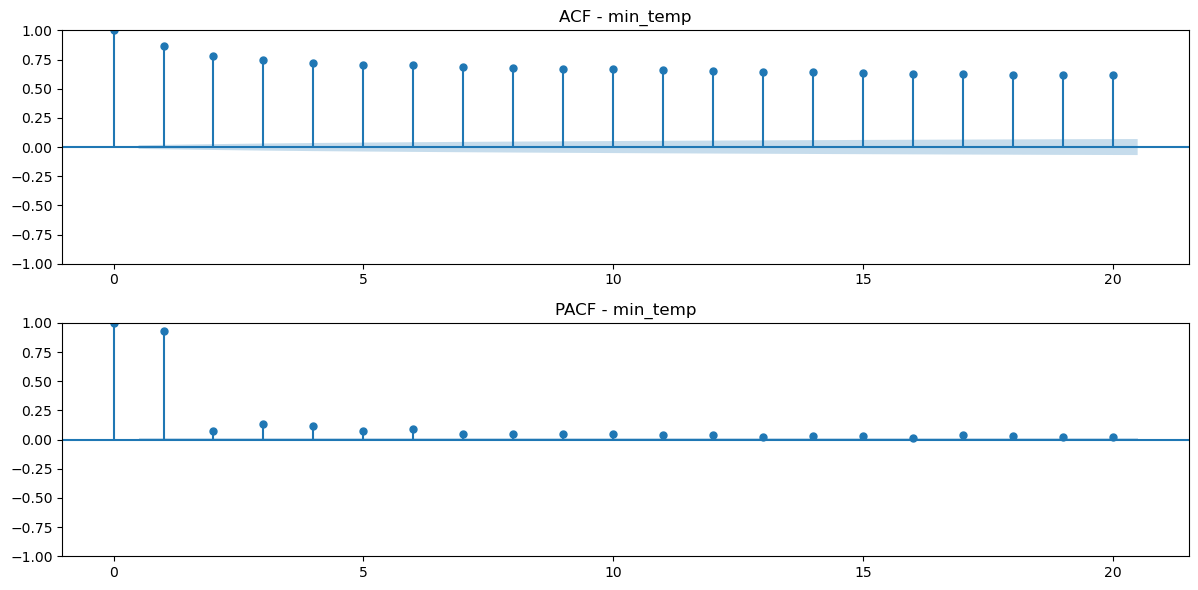

In [48]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plot_acf(df["min_temp"], lags=20, ax=plt.gca())  
plt.title("ACF - min_temp")

plt.subplot(2, 1, 2)
plot_pacf(df["mean_temp"], lags=20, ax=plt.gca())  
plt.title("PACF - min_temp")

plt.tight_layout()
plt.show()